# Multi-Pair Statistical Arbitrage Backtest

This notebook performs statistical arbitrage backtesting on multiple cointegrated stock pairs.

Steps:
1. Load cleaned price data
2. Identify cointegrated pairs
3. Run pairs trading strategy
4. Construct portfolio returns
5. Evaluate portfolio performance

In [1]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.stattools import coint

## Load Cleaned NIFTY 50 Price Data

This dataset contains daily closing prices of NIFTY 50 stocks.

In [2]:
# Load cleaned closing price data

close_prices = pd.read_csv(
    "../data/processed/nifty50_close_prices.csv",
    index_col="Date",
    parse_dates=True
)

# Display first few rows
close_prices.head()

,ADANIENT.NS,ADANIPORTS.NS,APOLLOHOSP.NS,ASIANPAINT.NS,AXISBANK.NS,BAJAJ-AUTO.NS,BAJFINANCE.NS,BAJAJFINSV.NS,BEL.NS,BAJAJHLDNG.NS,...,SBIN.NS,SUNPHARMA.NS,TCS.NS,TATACONSUM.NS,TATASTEEL.NS,TECHM.NS,TITAN.NS,ULTRACEMCO.NS,UPL.NS,WIPRO.NS
Date,,,,,,,,,,,,,,,,,,,,,
2017-11-17,84.019249,382.822540,1028.840210,1098.098999,539.474731,2572.177246,174.075928,511.221161,50.817471,2520.500000,...,311.416840,478.927338,1109.047119,243.298660,53.673950,366.711548,764.456909,4117.043945,444.631989,101.002823
2017-11-20,86.058052,380.578796,1033.473267,1093.458374,542.209961,2600.370361,175.819260,515.586121,51.116055,2526.324463,...,307.264618,478.973694,1107.469971,257.340546,53.746670,360.846313,762.172058,4034.308105,447.517670,100.729050
2017-11-21,82.329216,382.679321,1080.484619,1087.786255,543.850952,2647.092041,176.257553,518.840088,50.461998,2540.907715,...,305.096222,498.330811,1094.975342,255.702332,54.450886,373.749908,792.797058,4017.037354,463.235107,100.609291
2017-11-22,84.663078,395.759888,1121.156372,1100.911499,537.584961,2657.479004,172.770859,515.865173,51.286686,2547.932861,...,309.386871,495.737488,1098.129517,256.544800,54.427929,365.235840,790.560913,4081.681885,458.691833,100.711952
2017-11-23,81.819511,388.694489,1111.451782,1087.130005,541.215393,2618.537842,171.767700,511.604767,53.206192,2573.276367,...,309.063934,504.536224,1098.375366,257.246887,54.554237,370.533508,783.512329,4038.022949,459.981140,100.455299


## Identify Cointegrated Stock Pairs

We test every pair of stocks using the Engle-Granger cointegration test.
Pairs with p-value < 0.05 are considered cointegrated.

In [3]:
# Function to find cointegrated pairs

def find_cointegrated_pairs(data):

    n = data.shape[1]
    keys = data.columns
    pairs = []

    for i in range(n):
        for j in range(i + 1, n):

            s1 = data[keys[i]]
            s2 = data[keys[j]]

            score, pvalue, _ = coint(s1, s2)

            # Select statistically significant pairs
            if pvalue < 0.05:
                pairs.append((keys[i], keys[j]))

    return pairs

In [4]:
# Identify all cointegrated pairs

pairs = find_cointegrated_pairs(close_prices)

print("Cointegrated pairs found:", len(pairs))

# Show first few pairs
pairs[:10]
# show first few pairs
print("First 10 pairs:", pairs[:10])
print("Total pairs:", len(pairs))

Cointegrated pairs found: 103
First 10 pairs: [('ADANIPORTS.NS', 'APOLLOHOSP.NS'), ('ADANIPORTS.NS', 'AXISBANK.NS'), ('ADANIPORTS.NS', 'BAJAJ-AUTO.NS'), ('ADANIPORTS.NS', 'BRITANNIA.NS'), ('ADANIPORTS.NS', 'CIPLA.NS'), ('ADANIPORTS.NS', 'GRASIM.NS'), ('ADANIPORTS.NS', 'HINDALCO.NS'), ('ADANIPORTS.NS', 'SBILIFE.NS'), ('ADANIPORTS.NS', 'SUNPHARMA.NS'), ('ADANIPORTS.NS', 'TATASTEEL.NS')]
Total pairs: 103


## Initialize Portfolio Variables

We will:
- Track portfolio returns
- Count number of trades
- Store individual pair performance

In [5]:
# Initialize portfolio variables

portfolio_returns = pd.Series(0.0, index=close_prices.index)

trade_count = 0

pair_performance = {}

for stock1, stock2 in pairs:

    # Calculate spread
    spread = close_prices[stock1] - close_prices[stock2]

    # Z-score
    zscore = (spread - spread.mean()) / spread.std()

    # Generate position
    position = pd.Series(index=spread.index)

    position[zscore > 2] = -1
    position[zscore < -2] = 1

    position = position.fillna(0)

    # Strategy returns
    strategy_returns = position.shift(1) * spread.diff()

    # Total profit for pair
    pair_profit = strategy_returns.sum()

    pair_performance[(stock1, stock2)] = pair_profit

## Save Pair Performance Results

We save the profitability of each trading pair for further analysis.
This will be used in the next notebook for ranking and visualization.

In [6]:
# Sort pairs by profitability

sorted_pairs = sorted(pair_performance.items(), key=lambda x: x[1], reverse=True)

# Convert to DataFrame
pair_df = pd.DataFrame(sorted_pairs, columns=["pair","profit"])

# Save to processed data folder
pair_df.to_csv("../data/processed/pair_performance.csv", index=False)

print("Pair performance saved successfully")

Pair performance saved successfully


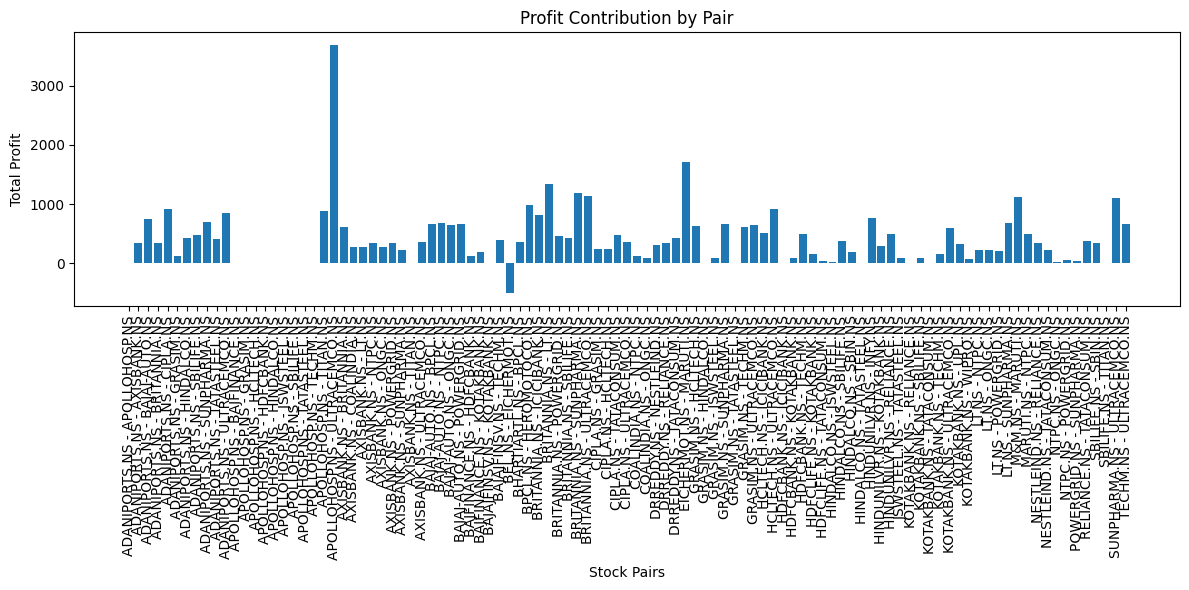

In [7]:
import matplotlib.pyplot as plt
pairs_list = [str(pair[0]) + " - " + str(pair[1]) for pair in pair_performance.keys()]
profits = list(pair_performance.values())

plt.figure(figsize=(12,6))
plt.bar(pairs_list, profits)

plt.xticks(rotation=90)
plt.title("Profit Contribution by Pair")
plt.xlabel("Stock Pairs")
plt.ylabel("Total Profit")

plt.tight_layout()
plt.savefig("../reports/pair_profit_distribution.png")
plt.show()

## Multi-Pair Backtesting

For each pair we:

1. Estimate hedge ratio using OLS regression
2. Compute spread
3. Calculate z-score
4. Generate trading signals
5. Compute strategy returns
6. Apply transaction costs
7. Aggregate portfolio returns

In [8]:
for stock1, stock2 in pairs:

    # Extract price series
    s1 = close_prices[stock1]
    s2 = close_prices[stock2]

    # Estimate hedge ratio using OLS regression
    X = sm.add_constant(s2)
    model = sm.OLS(s1, X).fit()

    beta = model.params[s2.name]

    # Compute spread
    spread = s1 - beta * s2

    # Rolling statistics
    window = 120

    rolling_mean = spread.rolling(window).mean()
    rolling_std = spread.rolling(window).std().replace(0, np.nan)

    # Compute z-score
    zscore = (spread - rolling_mean) / rolling_std

    # Initialize positions
    position = pd.Series(0, index=spread.index)

    entry = 2
    exit = 0.5

    # Trading signals
    position[zscore > entry] = -1
    position[zscore < -entry] = 1
    position[(zscore < exit) & (zscore > -exit)] = 0

    # Forward fill positions
    position = position.replace(0, np.nan).ffill().fillna(0)

    # Count trades
    trade_count += position.diff().abs().sum()

    # Compute returns
    returns1 = s1.pct_change().clip(-0.05, 0.05)
    returns2 = s2.pct_change().clip(-0.05, 0.05)

    pair_returns = returns1 - beta * returns2
    pair_returns = pair_returns.clip(-0.05, 0.05)

    positions = position.shift(1).fillna(0)

    trades = positions.diff().abs().fillna(0)

    cost = 0.0005
    transaction_cost = cost * trades

    strategy_returns = positions * pair_returns - transaction_cost
    strategy_returns = strategy_returns.fillna(0)
    # Volatility based weighting
    pair_vol = pair_returns.std()
    if pair_vol < 1e-6:
     pair_vol = 1e-6

    if pair_vol < 1e-6:
        weight = 0
    else:
        weight = 1 / pair_vol

    # cap maximum leverage to prevent extremely large weights
    weight = min(weight, 3)
    
    # Transaction cost
    cost = 0.0005  

    # Use shifted positions 
    positions = position.shift(1).fillna(0)

    # Detect trades
    trades = positions.diff().abs().fillna(0)

    # Transaction cost
    transaction_cost = cost * trades

    # Final strategy returns 
    strategy_returns = positions * pair_returns - transaction_cost
   
    # Store pair performance
    pair_performance[(stock1, stock2)] = strategy_returns.sum()

    # Update portfolio
    portfolio_returns += (weight / len(pairs)) * strategy_returns

    

### Regime Analysis

We evaluate strategy performance across different market regimes (pre and post COVID crash) to assess robustness under varying conditions.

In [9]:

# Regime Analysis (Bull vs Bear)


split_date = "2020-03-01"

bull = strategy_returns[strategy_returns.index < split_date]
bear = strategy_returns[strategy_returns.index >= split_date]

def sharpe(r):
    return np.sqrt(252) * r.mean() / r.std()

print("Bull Market Sharpe:", sharpe(bull))
print("Bear Market Sharpe:", sharpe(bear))


Bull Market Sharpe: 0.08627893096323917
Bear Market Sharpe: 0.5246757477065068


## Portfolio Equity Curve

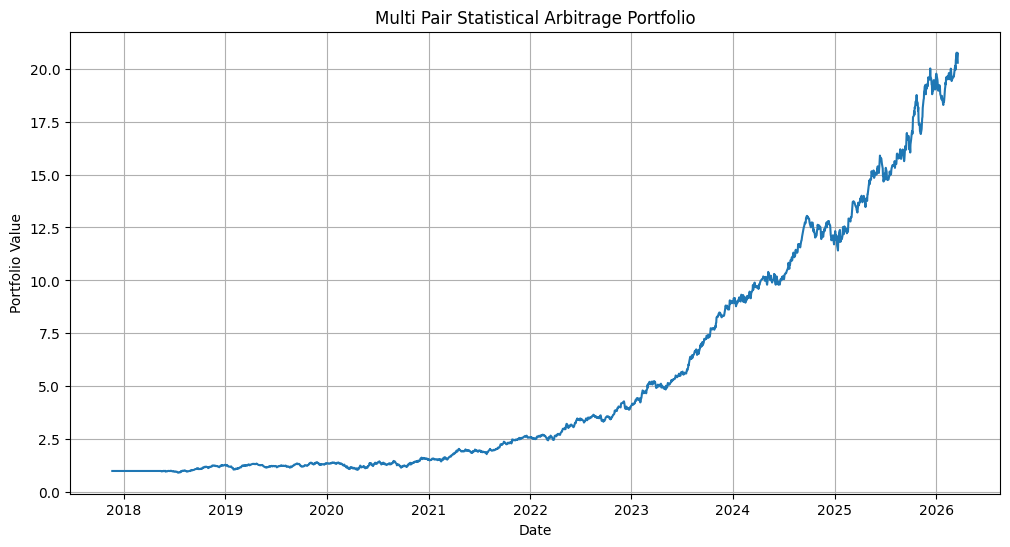

In [10]:
# Compute cumulative returns

cumulative_returns = (1 + portfolio_returns).cumprod()

plt.figure(figsize=(12,6))
plt.plot(cumulative_returns)

plt.title("Multi Pair Statistical Arbitrage Portfolio")
plt.xlabel("Date")
plt.ylabel("Portfolio Value")
plt.grid(True)
plt.savefig("../reports/equity_curve.png")
plt.show()

## Portfolio Performance Matrics

In [11]:
# Total return
total_return = cumulative_returns.iloc[-1] - 1

# Annualized return
annual_return = portfolio_returns.mean() * 252

# Volatility
volatility = portfolio_returns.std() * np.sqrt(252)

# Sharpe ratio
if portfolio_returns.std() != 0:
    sharpe = np.sqrt(252) * portfolio_returns.mean() / portfolio_returns.std()
else:
    sharpe = 0

# Drawdown
drawdown = cumulative_returns / cumulative_returns.cummax() - 1
max_dd = drawdown.min()

# Calmar ratio
calmar = annual_return / abs(max_dd)

print("Total Return:", total_return)
print("Annual Return:", annual_return)
print("Volatility:", volatility)
print("Sharpe Ratio:", sharpe)
print("Calmar Ratio:", calmar)
print("Max Drawdown:", max_dd)
print("Total trades:", trade_count)

Total Return: 19.279133298865847
Annual Return: 0.39501207531657684
Volatility: 0.230789023949219
Sharpe Ratio: 1.7115721907272863
Calmar Ratio: 1.5594095756162336
Max Drawdown: -0.2533087403676353
Total trades: 2493.0


In [12]:
metrics = pd.DataFrame({
    "Metric":[
        "Total Return",
        "Annual Return",
        "Volatility",
        "Sharpe Ratio",
        "Calmar Ratio",
        "Max Drawdown",
        "Total Trades"
    ],
    "Value":[
        total_return,
        annual_return,
        volatility,
        sharpe,
        calmar,
        max_dd,
        trade_count
    ]
})

metrics.to_csv("../data/processed/strategy_metrics.csv", index=False)

print("Strategy metrics saved")

Strategy metrics saved


In [13]:
# Save portfolio returns for analysis

portfolio_returns.to_csv("../data/processed/portfolio_returns.csv")

print("Portfolio returns saved successfully")

Portfolio returns saved successfully


## Conclusion

In this notebook we implemented a multi-pair statistical arbitrage strategy on NIFTY 50 stocks.

Key steps performed:

• Identified cointegrated stock pairs using the Engle–Granger test  
• Estimated hedge ratios using OLS regression  
• Generated trading signals using spread z-scores  
• Simulated trading with transaction costs  
• Aggregated returns across multiple pairs  
• Evaluated portfolio performance using key metrics  

The results show that combining multiple mean-reverting pairs can generate a diversified statistical arbitrage portfolio.

The next step is to analyze the profitability of individual pairs and identify the most reliable trading relationships.